<a href="https://colab.research.google.com/github/Xquisite-design/enterprise-presales-knowledge-orchestration/blob/main/notebooks/EDA_AIPresales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The Curated Enterprise Presales Research Corpus (CEPRC) consists of 900 annotated enterprise presales question–answer pairs represented by 29 variables. The dataset contains a combination of 23 categorical variables, 3 numerical variables, and 3 placeholder variables intended for future enhancement. Overall, the dataset is compact (approximately 204 KB) and suitable for exploratory analysis, statistical modelling, and machine learning

Since our dataset is an annotated enterprise presales corpus (around 900 observations with mostly categorical variables), I have elected to do EDA which is research-question driven rather than simply showing histograms and boxplots.

We will do the analysis in this order:

1. Dataset loading and inspection
2. Data quality assessment
3. Data cleaning log
4. Univariate EDA
5. Bivariate EDA (aligned to each Research Question)
6. Feature engineering
7. Statistical assumption checks
8. Baseline ML models
9. Preliminary evaluation
10. GitHub documentation

# 1. Dataset loading and inspection

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
import pandas as pd

df = pd.read_excel("/content/drive/MyDrive/DataAnalytics_Capstone/Enterprise_Presales_Knowledge_Research_Dataset_V1.xlsx", sheet_name='Enterprise_QA_Dataset')

print(df.shape)
print(df.info())

print(df.head())

print(df.describe(include='all'))

print(df.nunique())

print(df.isnull().sum())

print(df.duplicated().sum())

(900, 29)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 29 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Question_ID                       900 non-null    object 
 1   Vendor                            900 non-null    object 
 2   Source Website                    900 non-null    object 
 3   Question URL                      900 non-null    object 
 4   Source URL                        900 non-null    object 
 5   Question                          900 non-null    object 
 6   Official Answer                   900 non-null    object 
 7   Official Answer Summary           900 non-null    object 
 8   Official Documentation URL(s)     900 non-null    object 
 9   Knowledge Asset Category          900 non-null    object 
 10  Technology Domain                 900 non-null    object 
 11  Cloud Platform                    900 non-null    object 
 12

The above initial quality assessment indicates that the dataset is highly complete. All core research variables contain 900 non-null observations, while Publication Date, Accepted Answer Available?, and Accepted Answer URL contain no values because these fields were intentionally excluded from the current corpus. No duplicate observations were identified, confirming that each record represents a unique enterprise presales question–answer pair

Initial Observations

A few notable characteristics of the corpus emerge from the summary statistics:

- The dataset covers 8 technology vendors and 8 source websites, providing diversity across enterprise platforms.
- Question Type and Question Intent each contain 7 categories, aligning with the proposed inferential analyses for RQ2 and RQ4.
- The target variable Public Knowledge Only? contains two classes (Yes and Partially), confirming that Binary Logistic Regression is the appropriate statistical model for RQ1.
- Enterprise Knowledge Required contains 4 categories, supporting the planned Chi-square analyses.
- The variable Estimated RFP Relevance (1–5) has a mean score of 4.87, suggesting that the curated corpus primarily consists of questions that are highly relevant to enterprise presales.

#2. Dataset Quality Assessment

Before beginning exploratory analysis, the dataset is examined for completeness, duplicate records, data types, missing values, and the number of unique categories in each variable. This assessment helps identify potential data quality issues that may affect subsequent statistical analysis and machine learning models.

In [14]:
###############################################################
# DATA QUALITY ASSESSMENT
#
# This section evaluates the overall quality of the dataset.
# The following checks are performed:
#
# 1. Dataset dimensions
# 2. Data types
# 3. Missing values
# 4. Duplicate records
# 5. Unique values per variable
###############################################################

import pandas as pd

# Display number of rows and columns
print("="*60)
print("DATASET DIMENSIONS")
print("="*60)
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

# Display data types
print("\n")
print("="*60)
print("COLUMN DATA TYPES")
print("="*60)
print(df.dtypes)

# Missing values
print("\n")
print("="*60)
print("MISSING VALUES")
print("="*60)

missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': round(df.isnull().mean()*100,2)
})

print(missing)

# Duplicate records
print("\n")
print("="*60)
print("DUPLICATE RECORDS")
print("="*60)

duplicates = df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

# Number of unique values
print("\n")
print("="*60)
print("UNIQUE VALUES PER COLUMN")
print("="*60)

unique_values = pd.DataFrame({
    'Unique Values': df.nunique()
})

print(unique_values)

DATASET DIMENSIONS
Rows    : 900
Columns : 29


COLUMN DATA TYPES
Question_ID                          object
Vendor                               object
Source Website                       object
Question URL                         object
Source URL                           object
Question                             object
Official Answer                      object
Official Answer Summary              object
Official Documentation URL(s)        object
Knowledge Asset Category             object
Technology Domain                    object
Cloud Platform                       object
Presales Category                    object
Business Capability                  object
Question Intent                      object
Question Type                        object
Question Complexity                  object
Question Length                       int64
Number of Technologies Mentioned      int64
Document Type                        object
Publication Date                    float64
Tags      

The dataset was manually curated and annotated prior to analysis. Consequently, only basic quality checks such as missing values, duplicate records, and consistency of categorical labels are performed. Any identified issues are documented before proceeding with the exploratory analysis.

#3. Data Cleaning Log

In [15]:
###############################################################
# DATA CLEANING
#
# The purpose of this section is to identify any issues that
# require cleaning before statistical analysis.
#
# Checks performed:
#
# - Missing values
# - Duplicate records
# - Extra white spaces
# - Inconsistent category labels
###############################################################

# Remove leading and trailing spaces from all text columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

# Check missing values again
cleaning_log = pd.DataFrame({
    "Variable": df.columns,
    "Missing": df.isnull().sum(),
    "Unique Categories": df.nunique()
})

display(cleaning_log)

print("\nData Cleaning Completed.")

,Variable,Missing,Unique Categories
Question_ID,Question_ID,0,900
Vendor,Vendor,0,8
Source Website,Source Website,0,8
Question URL,Question URL,0,98
Source URL,Source URL,0,75
Question,Question,0,896
Official Answer,Official Answer,0,900
Official Answer Summary,Official Answer Summary,0,899
Official Documentation URL(s),Official Documentation URL(s),0,74
Knowledge Asset Category,Knowledge Asset Category,0,10



Data Cleaning Completed.


#4. Exploratory Data Analysis (Univariate)


Frequency Distribution : Vendor
Vendor
AWS             820
Databricks       25
IBM              24
Cisco            16
Google Cloud      8
Salesforce        4
Snowflake         2
Microsoft         1
Name: count, dtype: int64

Percentage Distribution
Vendor
AWS             91.11
Databricks       2.78
IBM              2.67
Cisco            1.78
Google Cloud     0.89
Salesforce       0.44
Snowflake        0.22
Microsoft        0.11
Name: proportion, dtype: float64


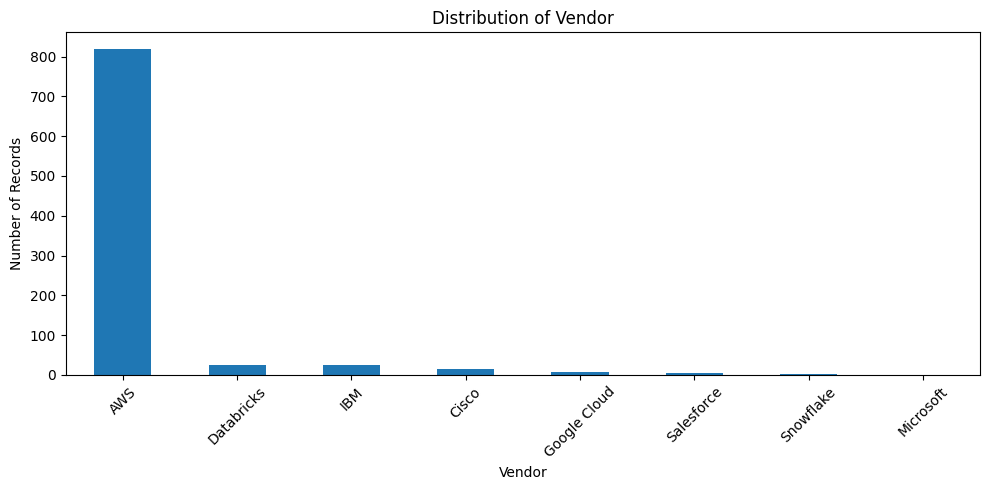


Frequency Distribution : Technology Domain
Technology Domain
Security / Governance            375
Networking                       207
GenAI / AI                       106
Analytics / Data Platform         76
Migration / Modernization         39
DevOps / Platform Engineering     35
Resilience / DR                   30
Cloud Architecture                16
Cost Optimization                 13
Operations / Monitoring            3
Name: count, dtype: int64

Percentage Distribution
Technology Domain
Security / Governance            41.67
Networking                       23.00
GenAI / AI                       11.78
Analytics / Data Platform         8.44
Migration / Modernization         4.33
DevOps / Platform Engineering     3.89
Resilience / DR                   3.33
Cloud Architecture                1.78
Cost Optimization                 1.44
Operations / Monitoring           0.33
Name: proportion, dtype: float64


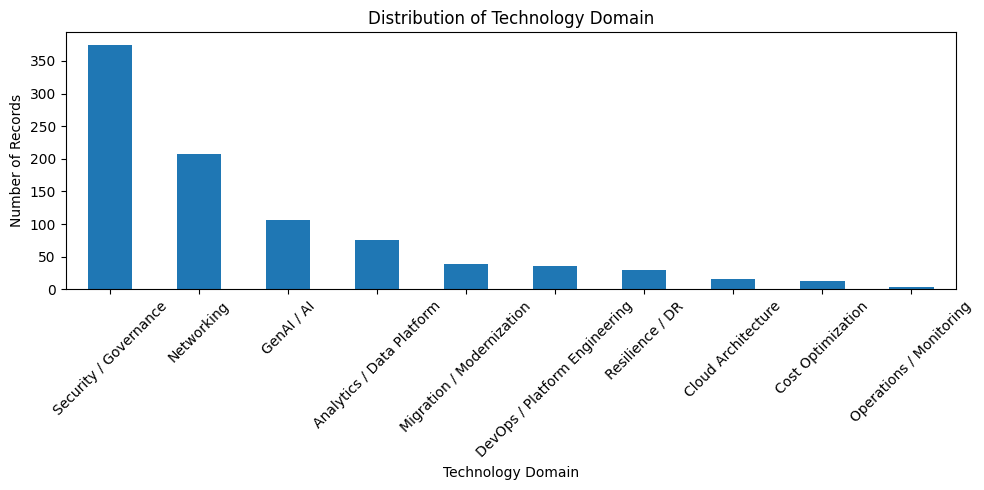


Frequency Distribution : Cloud Platform
Cloud Platform
AWS                                  820
Databricks                            25
IBM Cloud                             24
Cisco / Hybrid Network                16
Google Cloud                           8
Salesforce                             4
Snowflake                              2
Microsoft Azure / Microsoft Cloud      1
Name: count, dtype: int64

Percentage Distribution
Cloud Platform
AWS                                  91.11
Databricks                            2.78
IBM Cloud                             2.67
Cisco / Hybrid Network                1.78
Google Cloud                          0.89
Salesforce                            0.44
Snowflake                             0.22
Microsoft Azure / Microsoft Cloud     0.11
Name: proportion, dtype: float64


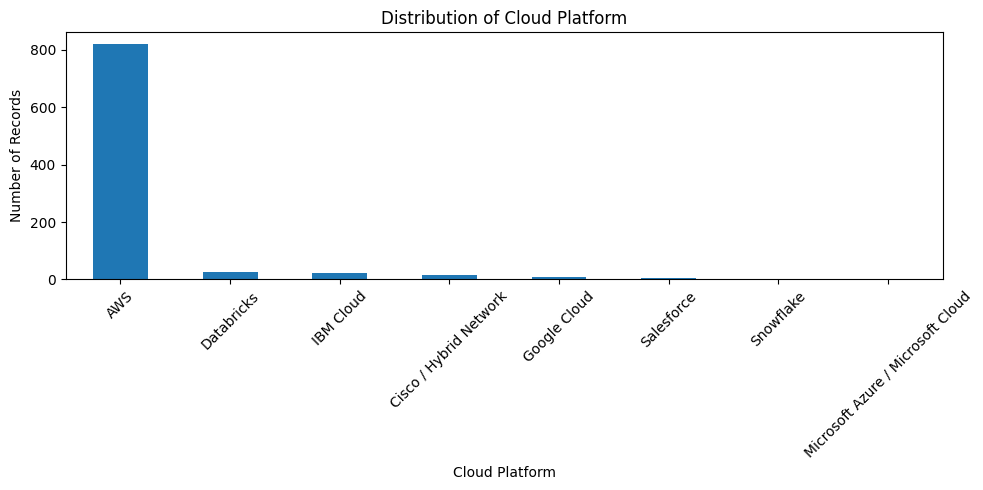


Frequency Distribution : Business Capability
Business Capability
Risk, compliance and identity control         375
Hybrid connectivity and network foundation    207
AI-enabled business capability                106
Enterprise data and analytics                  76
Cloud migration and modernization              39
Digital platform delivery                      35
Business continuity and resilience             30
Cloud foundation and workload architecture     16
Financial governance / FinOps                  13
IT operations and observability                 3
Name: count, dtype: int64

Percentage Distribution
Business Capability
Risk, compliance and identity control         41.67
Hybrid connectivity and network foundation    23.00
AI-enabled business capability                11.78
Enterprise data and analytics                  8.44
Cloud migration and modernization              4.33
Digital platform delivery                      3.89
Business continuity and resilience             3.33

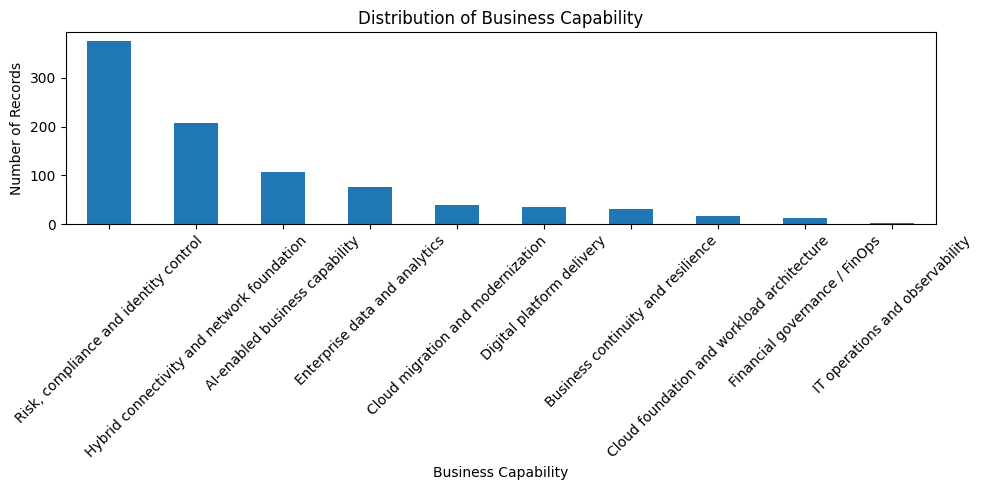


Frequency Distribution : Question Type
Question Type
Architecture             317
Commercial / Pricing     174
Best Practice            135
Governance / Security    123
Informational             65
Implementation            46
Migration                 40
Name: count, dtype: int64

Percentage Distribution
Question Type
Architecture             35.22
Commercial / Pricing     19.33
Best Practice            15.00
Governance / Security    13.67
Informational             7.22
Implementation            5.11
Migration                 4.44
Name: proportion, dtype: float64


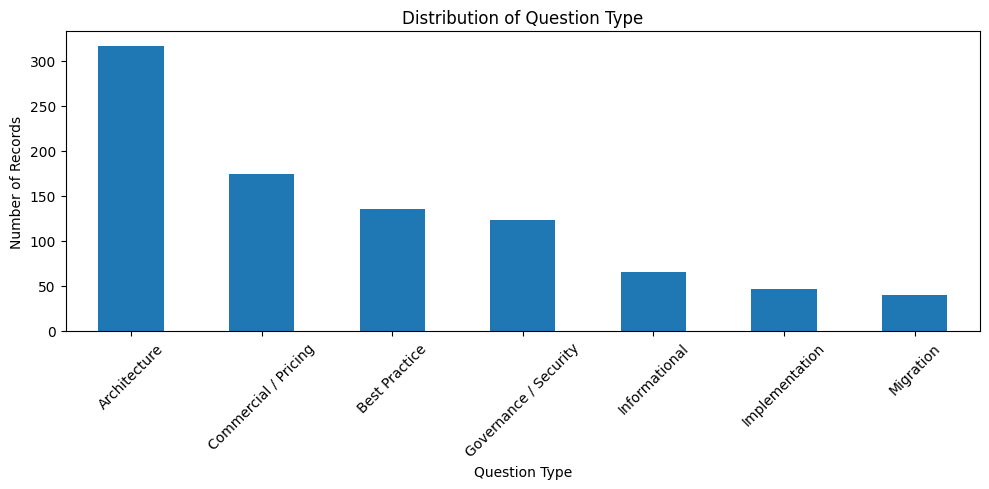


Frequency Distribution : Question Intent
Question Intent
Request presales guidance              364
Determine implementation approach      220
Understand capability / terminology    185
Evaluate options / fit                  39
Estimate commercial impact              36
Assess business rationale               30
Determine timing / applicability        26
Name: count, dtype: int64

Percentage Distribution
Question Intent
Request presales guidance              40.44
Determine implementation approach      24.44
Understand capability / terminology    20.56
Evaluate options / fit                  4.33
Estimate commercial impact              4.00
Assess business rationale               3.33
Determine timing / applicability        2.89
Name: proportion, dtype: float64


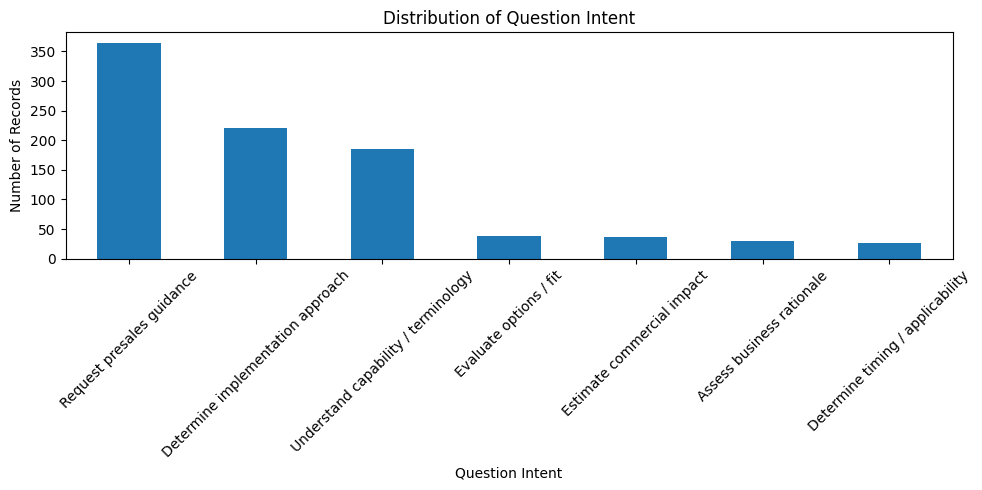


Frequency Distribution : Question Complexity
Question Complexity
High      690
Medium    163
Low        47
Name: count, dtype: int64

Percentage Distribution
Question Complexity
High      76.67
Medium    18.11
Low        5.22
Name: proportion, dtype: float64


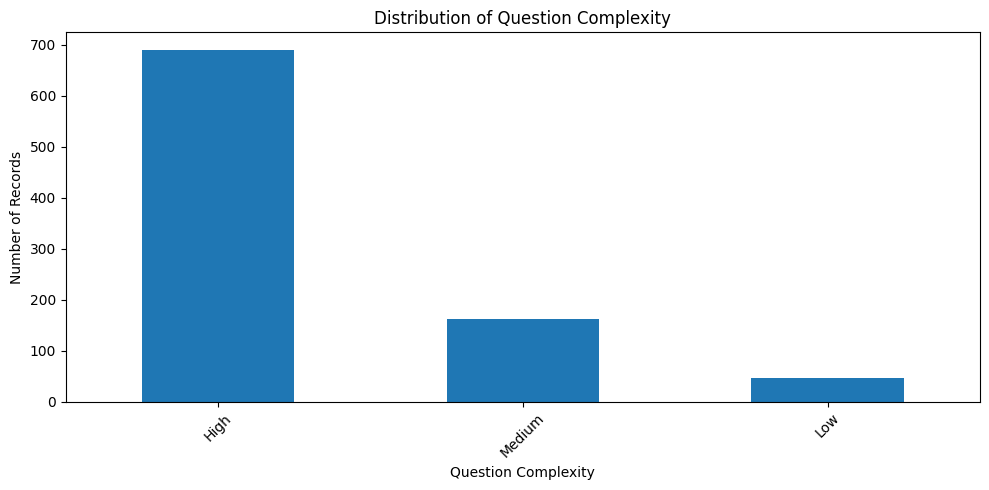


Frequency Distribution : Public Knowledge Only?
Public Knowledge Only?
Partially    754
Yes          146
Name: count, dtype: int64

Percentage Distribution
Public Knowledge Only?
Partially    83.78
Yes          16.22
Name: proportion, dtype: float64


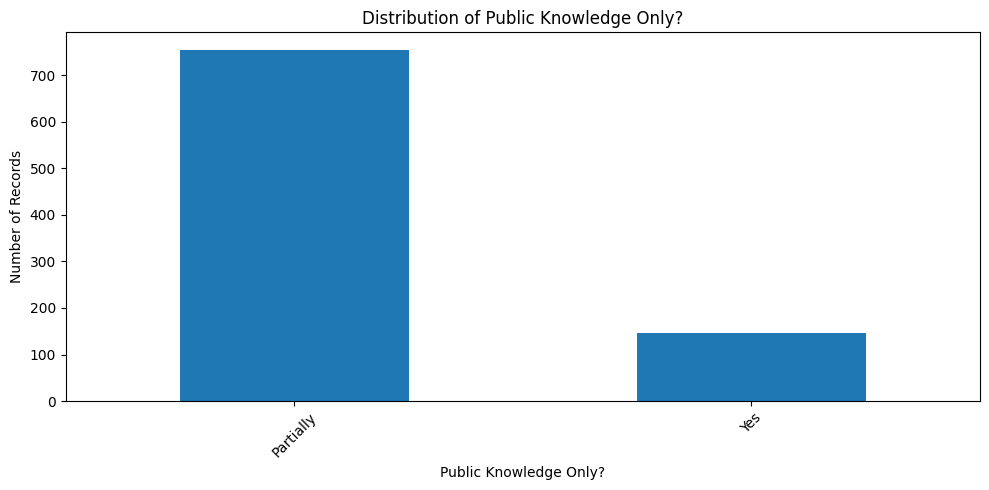


Frequency Distribution : Enterprise Knowledge Required
Enterprise Knowledge Required
Public Documentation | Architecture Blueprint | Methodology | SME    411
Public Documentation | Governance Framework | Risk Register | SME    190
Public Documentation | Commercial Model | Pricing Template | SME     153
Public Documentation                                                 146
Name: count, dtype: int64

Percentage Distribution
Enterprise Knowledge Required
Public Documentation | Architecture Blueprint | Methodology | SME    45.67
Public Documentation | Governance Framework | Risk Register | SME    21.11
Public Documentation | Commercial Model | Pricing Template | SME     17.00
Public Documentation                                                 16.22
Name: proportion, dtype: float64


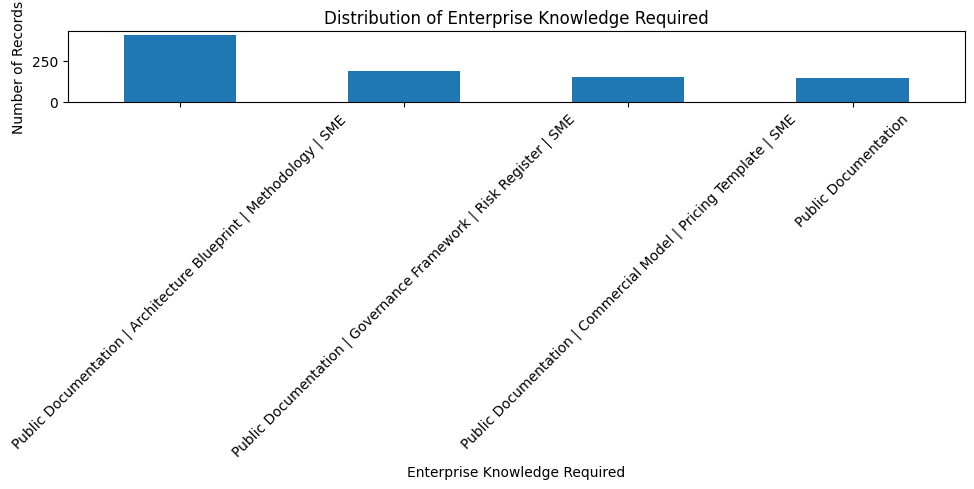

In [12]:
###############################################################
# EXPLORATORY DATA ANALYSIS (EDA)
#
# Objective:
# Understand the distribution of categorical variables before
# performing statistical analysis and machine learning.
#
# The following variables are analysed:
#   - Vendor
#   - Technology Domain
#   - Cloud Platform
#   - Business Capability
#   - Question Type
#   - Question Intent
#   - Question Complexity
#   - Public Knowledge Only?
#   - Enterprise Knowledge Required
###############################################################

import matplotlib.pyplot as plt

# List of important categorical variables
eda_columns = [
    'Vendor',
    'Technology Domain',
    'Cloud Platform',
    'Business Capability',
    'Question Type',
    'Question Intent',
    'Question Complexity',
    'Public Knowledge Only?',
    'Enterprise Knowledge Required'
]

# Loop through each variable
for col in eda_columns:

    print("\n" + "="*70)
    print(f"Frequency Distribution : {col}")
    print("="*70)

    # Display frequency table
    print(df[col].value_counts())

    # Display percentage distribution
    print("\nPercentage Distribution")
    print(round(df[col].value_counts(normalize=True)*100,2))

    # Plot bar chart
    plt.figure(figsize=(10,5))

    df[col].value_counts().plot(kind='bar')

    plt.title(f'Distribution of {col}')

    plt.ylabel('Number of Records')

    plt.xlabel(col)

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()

Frequency analysis was performed to understand the composition of the Curated Enterprise Presales Research Corpus (CEPRC) and assess whether the data adequately represents the research problem. The analysis shows that the corpus is intentionally centred on enterprise cloud technologies, with AWS contributing 820 of the 900 observations (91.1%), reflecting the greater availability of high-quality public documentation and enterprise technical discussions for AWS compared to other vendors. Smaller representations from Databricks, IBM, Cisco, Google Cloud, Salesforce, Snowflake and Microsoft were retained to introduce diversity across technology platforms rather than to achieve equal vendor representation.

The distribution of technology domains indicates that the corpus is dominated by Security/Governance (41.7%) and Networking (23.0%), followed by Generative AI (11.8%) and Analytics/Data Platform (8.4%). These distributions closely mirror the business capability categories because the annotation framework intentionally maps each technology domain to a corresponding enterprise business capability.

Analysis of question characteristics shows that Architecture (35.2%), Commercial/Pricing (19.3%), and Best Practice (15.0%) questions collectively account for nearly 70% of the corpus. Similarly, most questions seek presales guidance (40.4%) or implementation approaches (24.4%), indicating that the dataset primarily represents practical decision-making scenarios encountered during enterprise solution design.

Question complexity is intentionally skewed towards High complexity (76.7%), with only 5.2% classified as Low complexity. This reflects the research objective of evaluating AI-assisted enterprise presales, where questions frequently require contextual reasoning and the integration of multiple enterprise knowledge assets rather than simple factual retrieval.

The target variable Public Knowledge Only? shows that only 16.2% of questions can be answered using publicly available documentation alone, while 83.8% require additional enterprise knowledge. Likewise, the Enterprise Knowledge Required variable demonstrates that almost half of the corpus (45.7%) requires a combination of public documentation, architecture blueprints, implementation methodologies and subject matter expertise. These findings provide preliminary evidence that enterprise AI systems require effective knowledge orchestration beyond conventional Retrieval-Augmented Generation (RAG) to support presales activities.



Question Length
count    900.000000
mean      10.595556
std        4.769292
min        4.000000
25%        7.000000
50%       10.000000
75%       13.000000
max       40.000000
Name: Question Length, dtype: float64


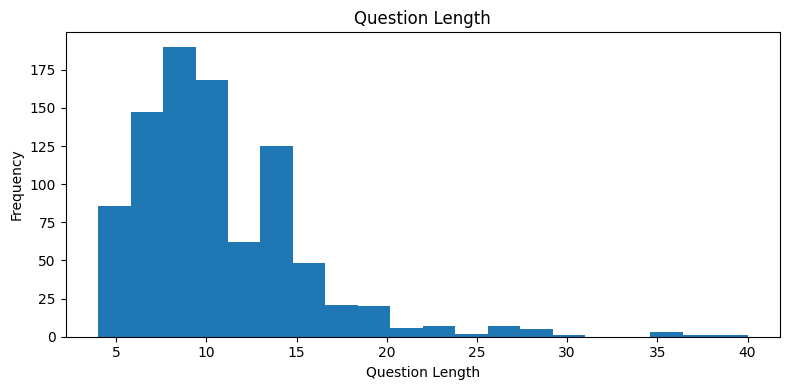



Number of Technologies Mentioned
count    900.000000
mean       2.742222
std        1.649551
min        0.000000
25%        2.000000
50%        3.000000
75%        4.000000
max       12.000000
Name: Number of Technologies Mentioned, dtype: float64


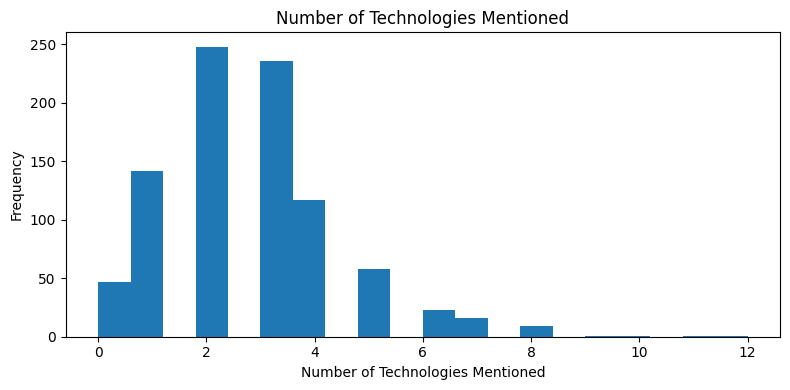



Estimated RFP Relevance (1-5)
count    900.000000
mean       4.873333
std        0.349097
min        3.000000
25%        5.000000
50%        5.000000
75%        5.000000
max        5.000000
Name: Estimated RFP Relevance (1-5), dtype: float64


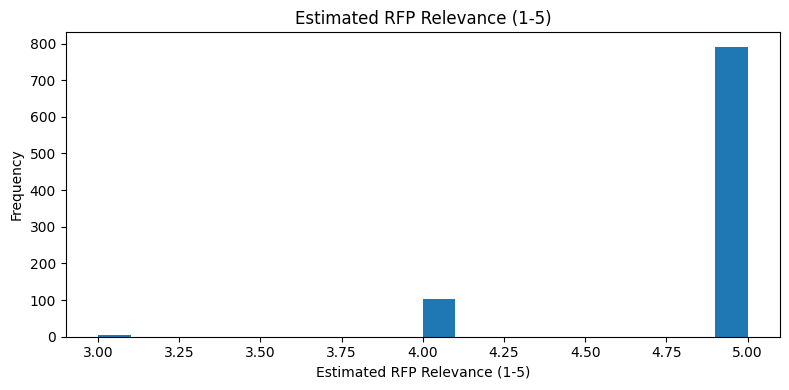

In [13]:
#Lets analyze the numerical variables.

###############################################################
# NUMERICAL VARIABLE ANALYSIS
#
# Analyse the numerical variables within the dataset.
###############################################################

numeric_columns = [
    'Question Length',
    'Number of Technologies Mentioned',
    'Estimated RFP Relevance (1-5)'
]

for col in numeric_columns:

    print("\n")
    print("="*60)
    print(col)
    print("="*60)

    print(df[col].describe())

    plt.figure(figsize=(8,4))

    plt.hist(df[col], bins=20)

    plt.title(col)

    plt.xlabel(col)

    plt.ylabel("Frequency")

    plt.tight_layout()

    plt.show()

Three numerical variables were analysed to understand the structural characteristics of the curated corpus. Enterprise presales questions contain an average of 10.6 words, with question lengths ranging from 4 to 40 words, indicating considerable variation in the complexity and specificity of user queries. Most questions fall between 7 and 13 words, suggesting that the corpus primarily consists of concise but information-rich enterprise questions.

The average number of technologies referenced within a single question is 2.74, with some questions mentioning up to 12 technologies. This observation reinforces the multi-technology nature of enterprise presales, where responses frequently require reasoning across multiple products, services or architectural components rather than focusing on a single technology.

The Estimated RFP Relevance score has a mean value of 4.87 out of 5, with more than half of the observations receiving the maximum rating. This confirms that the curated corpus predominantly contains questions that are highly representative of enterprise presales activities, making it suitable for evaluating AI-assisted knowledge orchestration

# 5. Predictor Association & Multicollinearity

CRAMER'S V ASSOCIATION MATRIX


,Question Type,Question Complexity,Technology Domain,Business Capability,Question Intent
Question Type,1.000,0.209,0.375,0.375,0.264
Question Complexity,0.209,1.000,0.631,0.631,0.102
Technology Domain,0.375,0.631,1.000,1.000,0.151
Business Capability,0.375,0.631,1.000,1.000,0.151
Question Intent,0.264,0.102,0.151,0.151,1.000


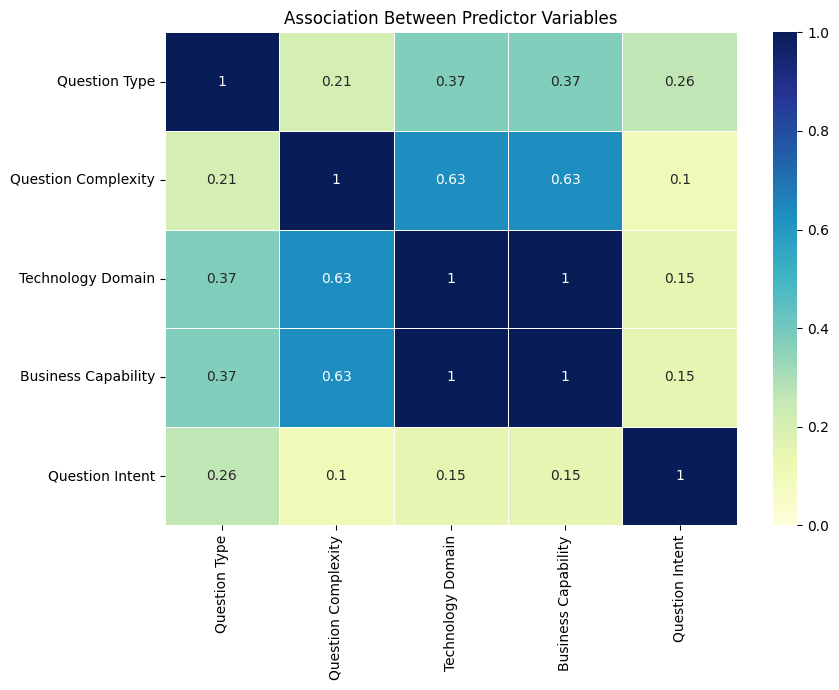



HIGHLY ASSOCIATED PREDICTOR PAIRS


,Predictor 1,Predictor 2,Cramer's V
0,Technology Domain,Business Capability,1.0




VARIANCE INFLATION FACTOR (VIF)


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Variable,VIF
12,Technology Domain_Migration / Modernization,inf
15,Technology Domain_Resilience / DR,inf
13,Technology Domain_Networking,inf
14,Technology Domain_Operations / Monitoring,inf
9,Technology Domain_Cost Optimization,inf
10,Technology Domain_DevOps / Platform Engineering,inf
8,Technology Domain_Cloud Architecture,inf
25,"Business Capability_Risk, compliance and ident...",inf
24,Business Capability_IT operations and observab...,inf
23,Business Capability_Hybrid connectivity and ne...,inf




VARIABLES WITH HIGH MULTICOLLINEARITY


,Variable,VIF
12,Technology Domain_Migration / Modernization,inf
15,Technology Domain_Resilience / DR,inf
13,Technology Domain_Networking,inf
14,Technology Domain_Operations / Monitoring,inf
9,Technology Domain_Cost Optimization,inf
10,Technology Domain_DevOps / Platform Engineering,inf
8,Technology Domain_Cloud Architecture,inf
25,"Business Capability_Risk, compliance and ident...",inf
24,Business Capability_IT operations and observab...,inf
23,Business Capability_Hybrid connectivity and ne...,inf




MODELLING RECOMMENDATION
Consider removing one variable from each highly associated pair.


In [27]:
###############################################################
# STEP 5
# ASSOCIATION AMONG PREDICTORS
# AND MULTICOLLINEARITY ANALYSIS
###############################################################

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency

from statsmodels.stats.outliers_influence import variance_inflation_factor

###############################################################
# Predictor Variables
###############################################################

predictors = [

    "Question Type",

    "Question Complexity",

    "Technology Domain",

    "Business Capability",

    "Question Intent"

]

###############################################################
# Function to calculate Cramer's V
###############################################################

def cramers_v(x, y):

    contingency = pd.crosstab(x, y)

    chi2 = chi2_contingency(contingency)[0]

    n = contingency.sum().sum()

    min_dim = min(contingency.shape)-1

    return np.sqrt(chi2/(n*min_dim))

###############################################################
# Create Association Matrix
###############################################################

association_matrix = pd.DataFrame(

    index=predictors,

    columns=predictors,

    dtype=float

)

for row in predictors:

    for col in predictors:

        association_matrix.loc[row, col] = cramers_v(df[row], df[col])

###############################################################
# Display Matrix
###############################################################

print("="*90)
print("CRAMER'S V ASSOCIATION MATRIX")
print("="*90)

display(association_matrix.round(3))

###############################################################
# Heatmap
###############################################################

plt.figure(figsize=(9,7))

sns.heatmap(

    association_matrix,

    annot=True,

    cmap="YlGnBu",

    vmin=0,

    vmax=1,

    linewidths=.5

)

plt.title("Association Between Predictor Variables")

plt.tight_layout()

plt.show()

###############################################################
# Identify Highly Associated Predictors
###############################################################

print("\n")

print("="*90)

print("HIGHLY ASSOCIATED PREDICTOR PAIRS")

print("="*90)

threshold = 0.80

redundant_pairs = []

for i in range(len(predictors)):

    for j in range(i+1, len(predictors)):

        value = association_matrix.iloc[i,j]

        if value >= threshold:

            redundant_pairs.append(

                [

                    predictors[i],

                    predictors[j],

                    round(value,3)

                ]

            )

if len(redundant_pairs)==0:

    print("No highly associated predictor pairs detected.")

else:

    redundant_df = pd.DataFrame(

        redundant_pairs,

        columns=[

            "Predictor 1",

            "Predictor 2",

            "Cramer's V"

        ]

    )

    display(redundant_df)

###############################################################
# STEP 5
# VIF ANALYSIS
###############################################################

print("\n")

print("="*90)

print("VARIANCE INFLATION FACTOR (VIF)")

print("="*90)

###############################################################
# One-hot encode predictors
###############################################################

X = pd.get_dummies(

    df[predictors],

    drop_first=True

)

###############################################################
# Convert boolean columns to integer
###############################################################

X = X.astype(int)

###############################################################
# Calculate VIF
###############################################################

vif = pd.DataFrame()

vif["Variable"] = X.columns

vif["VIF"] = [

    variance_inflation_factor(

        X.values,

        i

    )

    for i in range(X.shape[1])

]

vif = vif.sort_values(

    by="VIF",

    ascending=False

)

display(vif)

###############################################################
# Flag High VIF
###############################################################

print("\n")

print("="*90)

print("VARIABLES WITH HIGH MULTICOLLINEARITY")

print("="*90)

high_vif = vif[vif["VIF"]>5]

if len(high_vif)==0:

    print("No multicollinearity detected.")

else:

    display(high_vif)

###############################################################
# Overall Recommendation
###############################################################

print("\n")

print("="*90)

print("MODELLING RECOMMENDATION")

print("="*90)

if len(redundant_pairs)==0 and len(high_vif)==0:

    print("All predictors can be retained for Logistic Regression.")

elif len(redundant_pairs)>0:

    print("Consider removing one variable from each highly associated pair.")

elif len(high_vif)>0:

    print("Consider removing variables with high VIF values.")

The Cramér's V association matrix indicates that most predictor pairs exhibit weak to moderate associations, suggesting that they capture distinct aspects of enterprise presales questions. The only exception is Technology Domain and Business Capability, which show a perfect association (Cramér's V = 1.000), indicating that these variables contain identical information and are effectively duplicate representations of the same underlying concept. Moderate associations were observed between Question Complexity and both Technology Domain and Business Capability (Cramér's V = 0.631), while all remaining associations were below 0.40, indicating acceptable independence among predictors.

The VIF analysis further confirms this finding. All dummy variables corresponding to Technology Domain and Business Capability exhibit infinite VIF values, indicating perfect multicollinearity arising from the one-to-one mapping between these two variables. Additionally, three categories of Question Intent show VIF values between 5 and 10, suggesting moderate multicollinearity, although this is expected because one-hot encoded categories of the same variable are naturally correlated. No concerning multicollinearity was observed for Question Type or Question Complexity.

Based on these results, Business Capability and Technology Domain should not be included together in the Binary Logistic Regression model. Since both variables convey identical information, retaining only one avoids redundancy without sacrificing explanatory power. Given that this study investigates enterprise presales knowledge orchestration, Business Capability is the more appropriate variable because it better reflects business-oriented knowledge requirements and aligns more closely with the research objectives. Consequently, the final regression model should include Question Type, Question Complexity, Question Intent, and Business Capability, while excluding Technology Domain.

#6. RQ analysis

##6.1 RQ1 Analysis

Objective: This section explores the relationship between the characteristics of enterprise presales questions and whether they can be answered using publicly available knowledge alone or require additional enterprise knowledge.

The analysis serves two purposes:

- To understand the characteristics of the curated corpus.
- To identify variables that may be useful predictors for the Binary Logistic Regression model.

In [21]:
# Store statistical results for summary table
summary_results = []

In [24]:
###############################################################
# RQ EXPLORATORY ANALYSIS FUNCTION
#
# Performs:
# 1. Frequency Table
# 2. Percentage Table
# 3. Stacked Bar Chart
# 4. Chi-square Test
# 5. Cramer's V
# 6. Statistical Interpretation
###############################################################

import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import numpy as np

def analyze_predictor_vs_target(df, predictor, target):

    print("\n" + "="*80)
    print(f"Analyzing: {predictor} vs {target}")
    print("="*80)

    try:
        # ----------------------------------------------------------
        # Cross Tabulation
        # ----------------------------------------------------------

        contingency = pd.crosstab(df[predictor], df[target])

        print("\nContingency Table\n")
        display(contingency)

        # ----------------------------------------------------------
        # Row Percentages
        # ----------------------------------------------------------

        percentage = pd.crosstab(
            df[predictor],
            df[target],
            normalize='index'
        ) * 100

        print("\nPercentage Distribution\n")
        display(percentage.round(2))

        # ----------------------------------------------------------
        # Stacked Bar Chart
        # ----------------------------------------------------------

        ax = percentage.plot(
            kind='bar',
            stacked=True,
            figsize=(10,6)
        )

        plt.title(f"{predictor} vs {target}")

        plt.ylabel("Percentage")

        plt.xlabel(predictor)

        plt.xticks(rotation=30)

        plt.legend(title=target)

        plt.tight_layout()

        plt.show()

        # ----------------------------------------------------------
        # Chi-square Test
        # ----------------------------------------------------------

        chi2, p, dof, expected = chi2_contingency(contingency)

        print("\n")
        print("="*60)
        print("Chi-square Test")
        print("="*60)

        print(f"Chi-square Statistic : {chi2:.3f}")

        print(f"Degrees of Freedom   : {dof}")

        print(f"P-value              : {p:.5f}")

        # ----------------------------------------------------------
        # Cramer's V
        # ----------------------------------------------------------

        n = contingency.sum().sum()

        # Ensure min_dim is not zero to prevent ZeroDivisionError
        min_dim = min(contingency.shape) - 1
        if min_dim == 0:
            cramers_v = np.nan # Or handle as appropriate, e.g., 0 or skip
            print("Cramer's V: Cannot be calculated (min_dim is 0).")
        else:
            cramers_v = np.sqrt(chi2/(n*min_dim))
            print(f"Cramer's V           : {cramers_v:.3f}")

        # ----------------------------------------------------------
        # Interpretation
        # ----------------------------------------------------------

        print("\n")
        print("="*60)
        print("Interpretation")
        print("="*60)

        if p < 0.05:
            print("✓ Reject the Null Hypothesis")
            print("There is a statistically significant association.")

        else:
            print("✓ Fail to Reject the Null Hypothesis")
            print("No statistically significant association detected.")

        if pd.isna(cramers_v) or cramers_v < 0.10:
            strength = "Negligible"

        elif cramers_v < 0.30:
            strength = "Weak"

        elif cramers_v < 0.50:
            strength = "Moderate"

        else:
            strength = "Strong"

        print(f"Association Strength : {strength}")

        print("\nSuggested for Logistic Regression:")

        if p < 0.05:
            print("YES")

        else:
            print("Consider excluding this predictor.")

        # ----------------------------------------------------------
        # Store Results
        # ----------------------------------------------------------

        if pd.isna(cramers_v) or cramers_v < 0.10:
            effect = "Negligible"
        elif cramers_v < 0.30:
            effect = "Weak"
        elif cramers_v < 0.50:
            effect = "Moderate"
        else:
            effect = "Strong"

        summary_results.append({

            "Predictor": predictor,

            "Chi-square": round(chi2,3),

            "Degrees of Freedom": dof,

            "P-value": round(p,5),

            "Cramer's V": round(cramers_v,3) if not pd.isna(cramers_v) else cramers_v,

            "Effect Size": effect,

            "Statistically Significant":
                "Yes" if p < 0.05 else "No",

            "Include in Logistic Regression":
                "Yes" if p < 0.05 else "No"

        })
    except Exception as e:
        print(f"An error occurred while processing {predictor}: {e}")
        print("Skipping this predictor and continuing with the next ones if any.")


Analyzing: Question Type vs Public Knowledge Only?

Contingency Table



Public Knowledge Only?,Partially,Yes
Question Type,,
Architecture,255,62
Best Practice,118,17
Commercial / Pricing,150,24
Governance / Security,109,14
Implementation,42,4
Informational,45,20
Migration,35,5



Percentage Distribution



Public Knowledge Only?,Partially,Yes
Question Type,,
Architecture,80.44,19.56
Best Practice,87.41,12.59
Commercial / Pricing,86.21,13.79
Governance / Security,88.62,11.38
Implementation,91.30,8.70
Informational,69.23,30.77
Migration,87.50,12.50


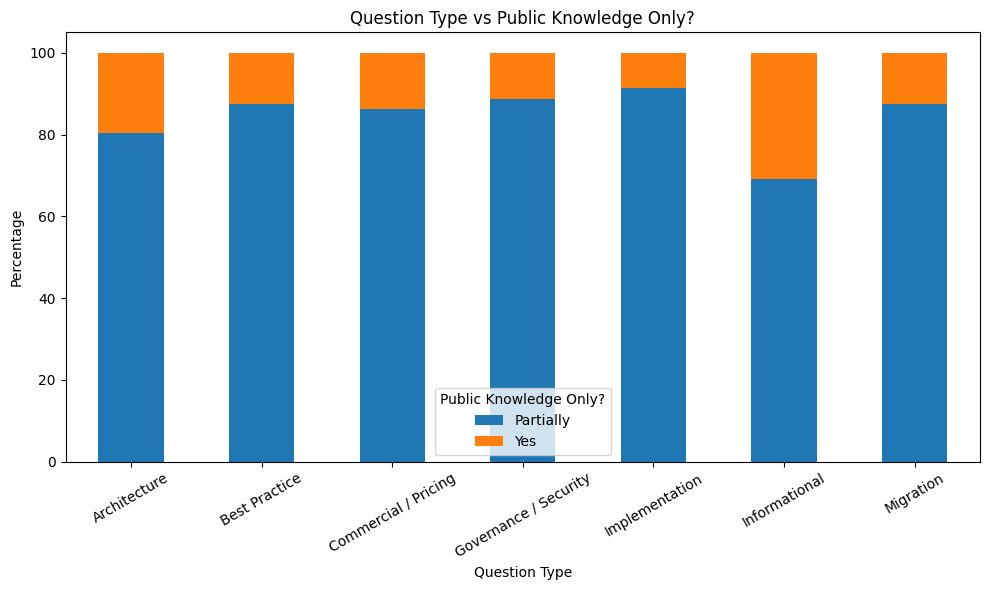



Chi-square Test
Chi-square Statistic : 19.226
Degrees of Freedom   : 6
P-value              : 0.00380
Cramer's V           : 0.146


Interpretation
✓ Reject the Null Hypothesis
There is a statistically significant association.
Association Strength : Weak

Suggested for Logistic Regression:
YES

Analyzing: Question Complexity vs Public Knowledge Only?

Contingency Table



Public Knowledge Only?,Partially,Yes
Question Complexity,,
High,590,100
Low,33,14
Medium,131,32



Percentage Distribution



Public Knowledge Only?,Partially,Yes
Question Complexity,,
High,85.51,14.49
Low,70.21,29.79
Medium,80.37,19.63


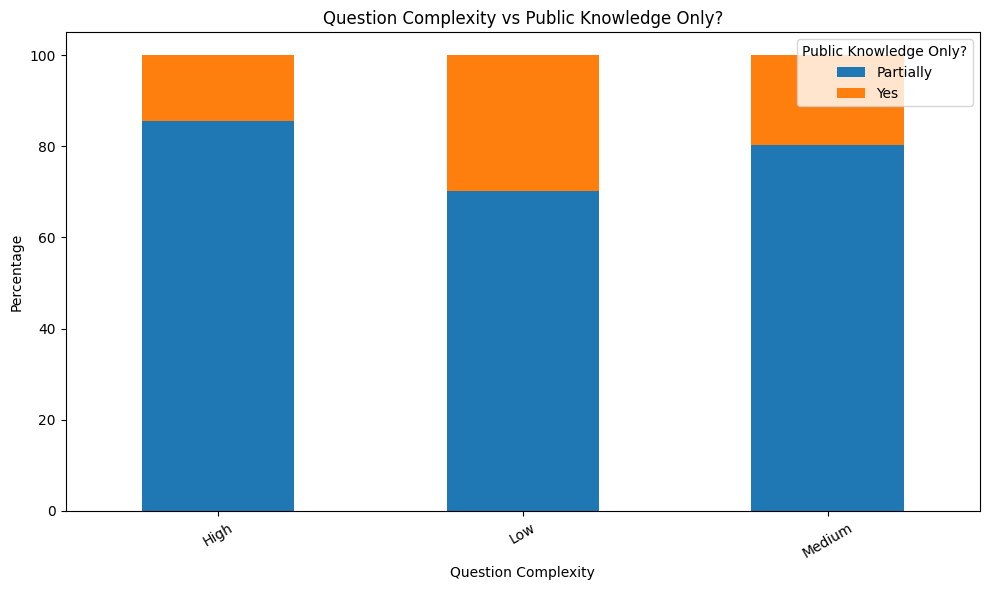



Chi-square Test
Chi-square Statistic : 9.276
Degrees of Freedom   : 2
P-value              : 0.00967
Cramer's V           : 0.102


Interpretation
✓ Reject the Null Hypothesis
There is a statistically significant association.
Association Strength : Weak

Suggested for Logistic Regression:
YES

Analyzing: Technology Domain vs Public Knowledge Only?

Contingency Table



Public Knowledge Only?,Partially,Yes
Technology Domain,,
Analytics / Data Platform,65,11
Cloud Architecture,11,5
Cost Optimization,12,1
DevOps / Platform Engineering,29,6
GenAI / AI,81,25
Migration / Modernization,37,2
Networking,167,40
Operations / Monitoring,0,3
Resilience / DR,28,2



Percentage Distribution



Public Knowledge Only?,Partially,Yes
Technology Domain,,
Analytics / Data Platform,85.53,14.47
Cloud Architecture,68.75,31.25
Cost Optimization,92.31,7.69
DevOps / Platform Engineering,82.86,17.14
GenAI / AI,76.42,23.58
Migration / Modernization,94.87,5.13
Networking,80.68,19.32
Operations / Monitoring,0.00,100.00
Resilience / DR,93.33,6.67


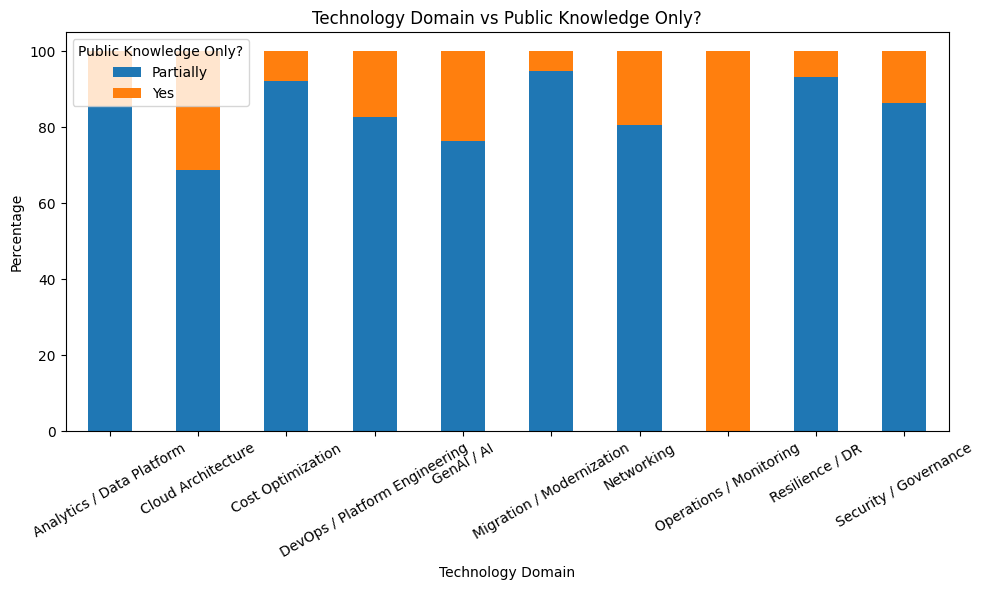



Chi-square Test
Chi-square Statistic : 32.178
Degrees of Freedom   : 9
P-value              : 0.00019
Cramer's V           : 0.189


Interpretation
✓ Reject the Null Hypothesis
There is a statistically significant association.
Association Strength : Weak

Suggested for Logistic Regression:
YES

Analyzing: Business Capability vs Public Knowledge Only?

Contingency Table



Public Knowledge Only?,Partially,Yes
Business Capability,,
AI-enabled business capability,81,25
Business continuity and resilience,28,2
Cloud foundation and workload architecture,11,5
Cloud migration and modernization,37,2
Digital platform delivery,29,6
Enterprise data and analytics,65,11
Financial governance / FinOps,12,1
Hybrid connectivity and network foundation,167,40
IT operations and observability,0,3



Percentage Distribution



Public Knowledge Only?,Partially,Yes
Business Capability,,
AI-enabled business capability,76.42,23.58
Business continuity and resilience,93.33,6.67
Cloud foundation and workload architecture,68.75,31.25
Cloud migration and modernization,94.87,5.13
Digital platform delivery,82.86,17.14
Enterprise data and analytics,85.53,14.47
Financial governance / FinOps,92.31,7.69
Hybrid connectivity and network foundation,80.68,19.32
IT operations and observability,0.00,100.00


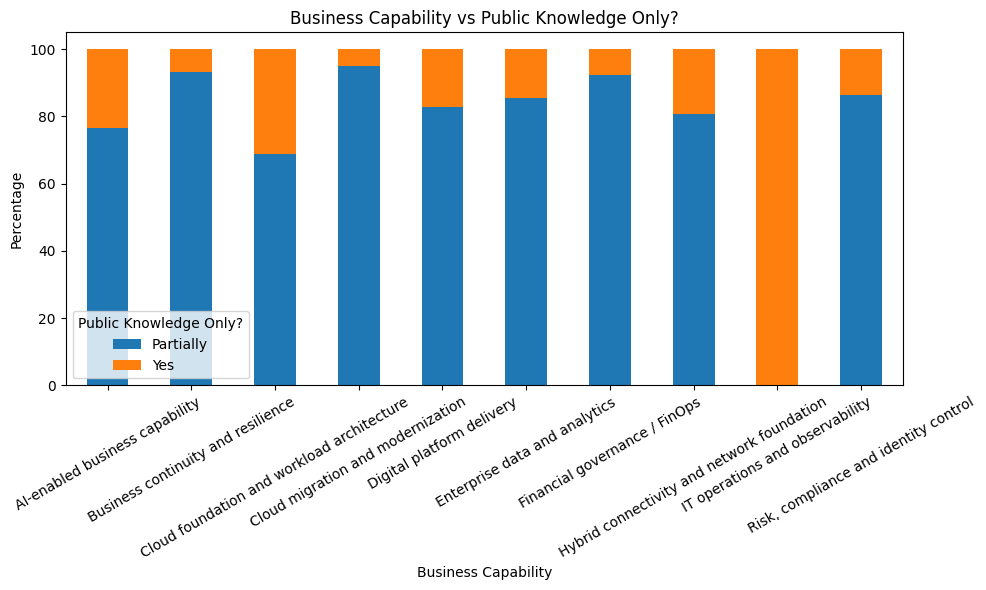



Chi-square Test
Chi-square Statistic : 32.178
Degrees of Freedom   : 9
P-value              : 0.00019
Cramer's V           : 0.189


Interpretation
✓ Reject the Null Hypothesis
There is a statistically significant association.
Association Strength : Weak

Suggested for Logistic Regression:
YES

Analyzing: Question Intent vs Public Knowledge Only?

Contingency Table



Public Knowledge Only?,Partially,Yes
Question Intent,,
Assess business rationale,30,0
Determine implementation approach,208,12
Determine timing / applicability,26,0
Estimate commercial impact,35,1
Evaluate options / fit,35,4
Request presales guidance,310,54
Understand capability / terminology,110,75



Percentage Distribution



Public Knowledge Only?,Partially,Yes
Question Intent,,
Assess business rationale,100.00,0.00
Determine implementation approach,94.55,5.45
Determine timing / applicability,100.00,0.00
Estimate commercial impact,97.22,2.78
Evaluate options / fit,89.74,10.26
Request presales guidance,85.16,14.84
Understand capability / terminology,59.46,40.54


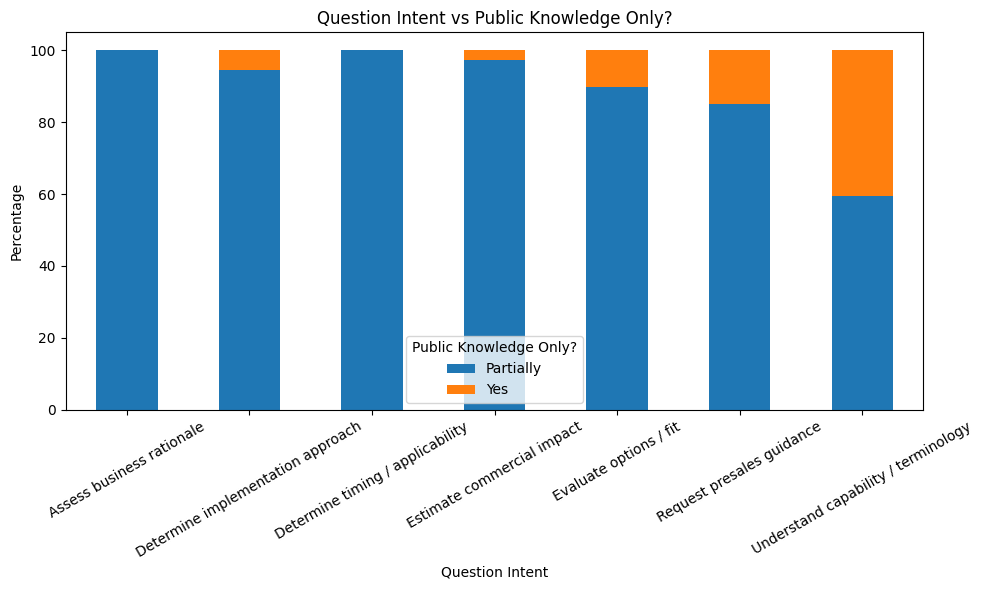



Chi-square Test
Chi-square Statistic : 116.437
Degrees of Freedom   : 6
P-value              : 0.00000
Cramer's V           : 0.360


Interpretation
✓ Reject the Null Hypothesis
There is a statistically significant association.
Association Strength : Moderate

Suggested for Logistic Regression:
YES


In [25]:
# RQ1 Predictor Analysis

target = "Public Knowledge Only?"

predictors = [

    "Question Type",

    "Question Complexity",

    "Technology Domain",

    "Business Capability",

    "Question Intent"

]

for predictor in predictors:

    analyze_predictor_vs_target(df, predictor, target)

In [26]:
###############################################################
# SUMMARY OF ALL PREDICTOR ANALYSES
###############################################################

summary_df = pd.DataFrame(summary_results)

summary_df = summary_df.sort_values(
    by="Cramer's V",
    ascending=False
)

print("="*90)
print("SUMMARY OF EXPLORATORY INFERENTIAL ANALYSIS")
print("="*90)

display(summary_df)

SUMMARY OF EXPLORATORY INFERENTIAL ANALYSIS


,Predictor,Chi-square,Degrees of Freedom,P-value,Cramer's V,Effect Size,Statistically Significant,Include in Logistic Regression
4,Question Intent,116.437,6,0.00000,0.360,Moderate,Yes,Yes
3,Business Capability,32.178,9,0.00019,0.189,Weak,Yes,Yes
2,Technology Domain,32.178,9,0.00019,0.189,Weak,Yes,Yes
0,Question Type,19.226,6,0.00380,0.146,Weak,Yes,Yes
1,Question Complexity,9.276,2,0.00967,0.102,Weak,Yes,Yes


An exploratory inferential analysis was conducted to examine the association between each candidate predictor and the target variable (Public Knowledge Only?) prior to model development. Chi-square tests indicated that Question Type, Question Complexity, Technology Domain, Business Capability, and Question Intent were all significantly associated with the target variable (p < 0.05). Although most relationships exhibited weak effect sizes (Cramér's V = 0.10–0.19), Question Intent demonstrated a moderate association (Cramér's V = 0.36), suggesting that the intent behind a presales question is the strongest indicator of whether enterprise knowledge is required. Consequently, all five predictors were retained for the subsequent Binary Logistic Regression analysis.